## Phase 1 - Data loading

In [1]:
# ── Phase 1: Setup & Data Loading ───────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# --- 1. Load the dataset ---
df = pd.read_csv('../data/telco_churn.csv')

# --- 2. First look ---
print("Shape:", df.shape)         
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

# --- 3. Data types and missing values ---
print("\nInfo:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

# --- 4. Target variable check ---
print("\nChurn value counts:")
print(df['Churn'].value_counts())
print("\nChurn %:")
print(df['Churn'].value_counts(normalize=True).mul(100).round(1))

Matplotlib is building the font cache; this may take a moment.


Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 no

You'll notice roughly 73% "No" and 27% "Yes" — this class imbalance is something we'll handle in Phase 4.

In [2]:
# TotalCharges is stored as a string — fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many rows got NaN from the conversion
print("NaN after conversion:", df['TotalCharges'].isnull().sum())

# Drop those rows (they're new customers with no charges yet)
df.dropna(subset=['TotalCharges'], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Clean shape:", df.shape)

NaN after conversion: 11
Clean shape: (7032, 21)


## Phase 2 - Exploratory Data Analysis (EDA)

### Step 1 - Understand target Variable - 'class' imbalance

Churn
No     5163
Yes    1869
Name: count, dtype: int64


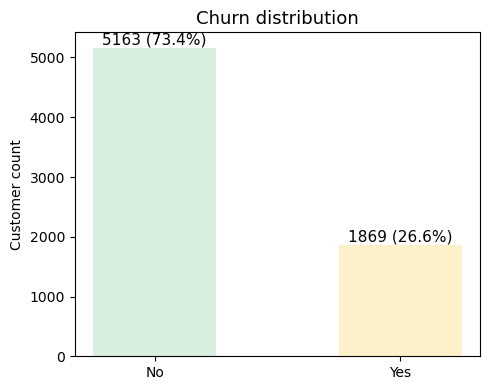

In [3]:
# ── Phase 2: EDA ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Reload if starting fresh
df = pd.read_csv('../data/telco_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df.reset_index(drop=True, inplace= True)

# --- Churn distribution ---
churn_counts= df['Churn'].value_counts()
print(churn_counts)

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#D8EEDF', '#FDF1C9']
ax.bar(churn_counts.index, churn_counts.values, color=colors, width=0.5)
ax.set_title('Churn distribution', fontsize=13)
ax.set_ylabel('Customer count')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 50, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../data/churn_distribution.png', dpi=150)
plt.show()

### Step 2 - Explore numerical features

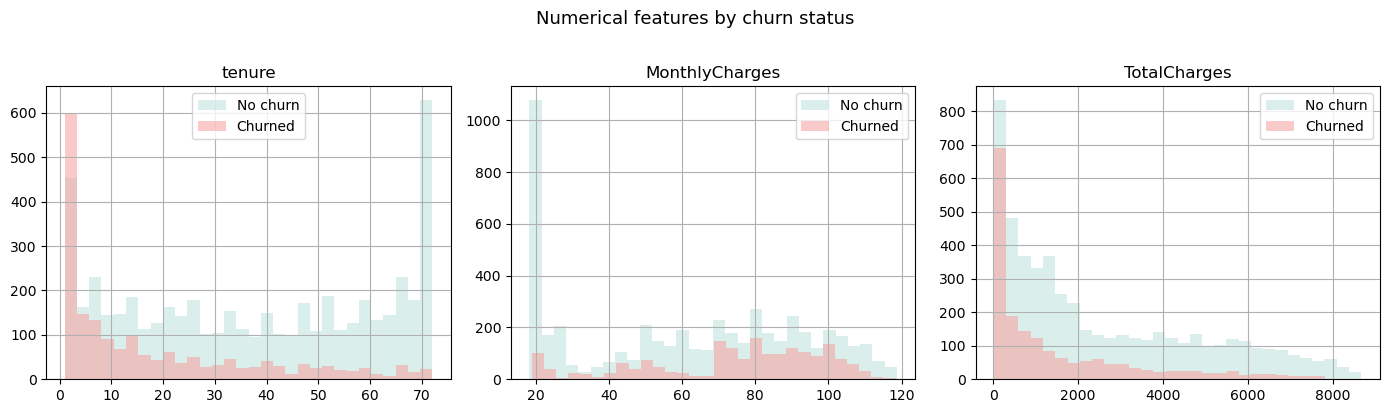

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.65           61.31       2555.34
Yes     17.98           74.44       1531.80


In [4]:
# --- Numerical feature distributions by churn ---
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    df[df['Churn'] == 'No'][col].hist(ax=ax, bins=30, alpha=0.6,
                                       color='#C2E5DF', label='No churn')
    df[df['Churn'] == 'Yes'][col].hist(ax=ax, bins=30, alpha=0.6,
                                        color='#F5A7A6', label='Churned')
    ax.set_title(col)
    ax.legend()
plt.suptitle('Numerical features by churn status', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('../data/numerical_distributions.png', dpi=150)
plt.show()

# Print summary stats
print(df.groupby('Churn')[num_cols].mean().round(2))

### Step 3 - Explore categoircal features

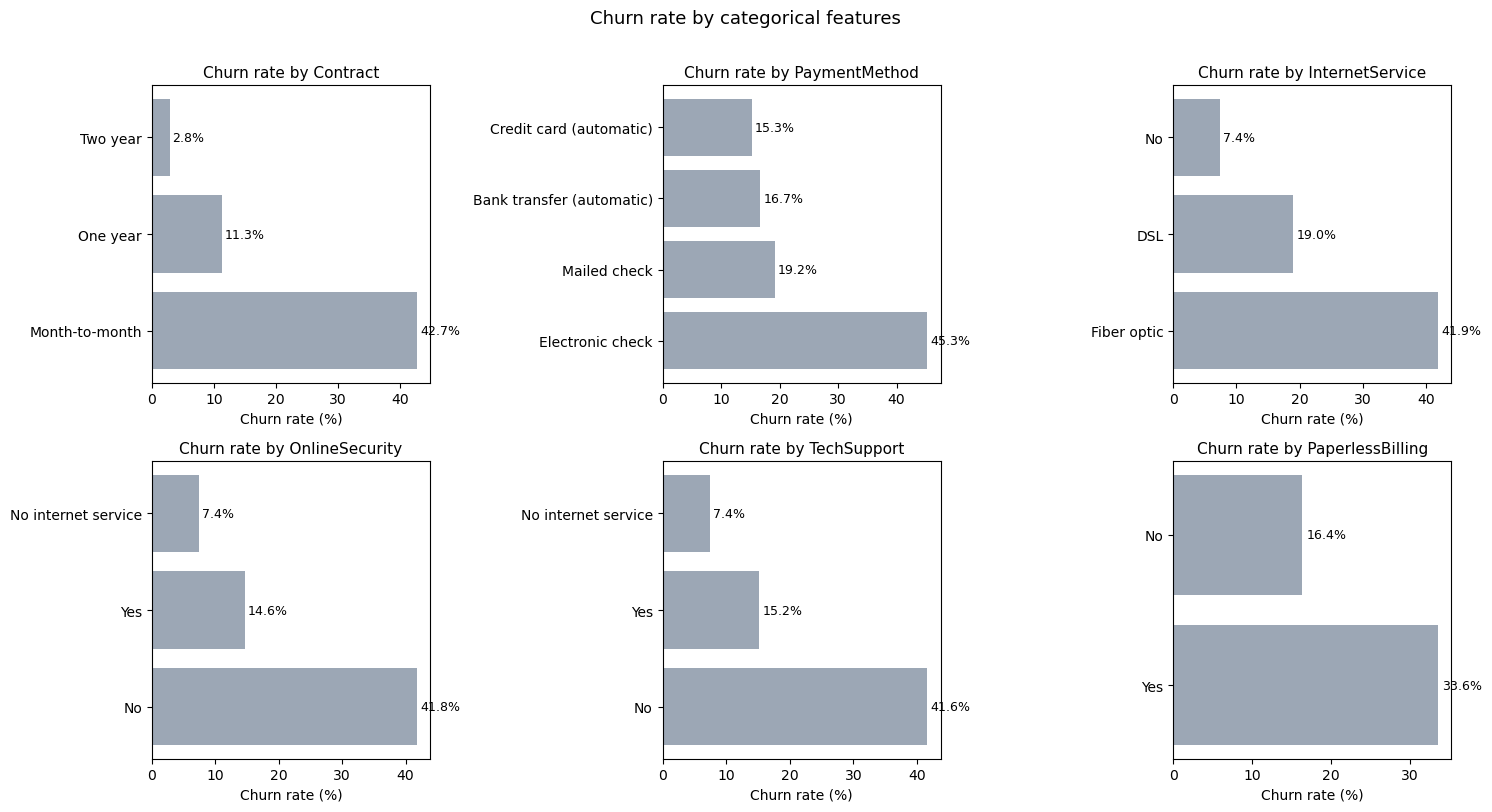

In [5]:
# --- Churn rate by key categorical features ---
cat_cols = ['Contract', 'PaymentMethod', 'InternetService',
            'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    churn_rate.columns = [col, 'Churn Rate (%)']
    churn_rate = churn_rate.sort_values('Churn Rate (%)', ascending=False)

    bars = ax.barh(churn_rate[col], churn_rate['Churn Rate (%)'],
                   color='#8391A3', alpha=0.8)
    ax.set_title(f'Churn rate by {col}', fontsize=11)
    ax.set_xlabel('Churn rate (%)')
    for bar, val in zip(bars, churn_rate['Churn Rate (%)']):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Churn rate by categorical features', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/categorical_churn_rates.png', dpi=150)
plt.show()

### Step 4 - Correlation heatmap

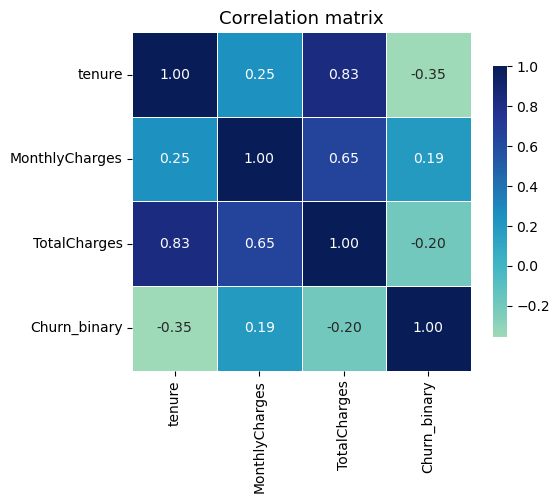

In [6]:
# --- Correlation heatmap (numerical only) ---
# Convert Churn to binary first
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap="YlGnBu",
            center=0, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix', fontsize=13)
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150)
plt.show()

### Step 5 - Key insights summary

In [7]:
# --- Print key EDA insights ---
print("=== KEY EDA FINDINGS ===\n")

# Tenure: churned vs not
avg_tenure = df.groupby('Churn')['tenure'].mean()
print(f"Avg tenure (No churn): {avg_tenure['No']:.1f} months")
print(f"Avg tenure (Churned):  {avg_tenure['Yes']:.1f} months\n")

# Monthly charges
avg_monthly = df.groupby('Churn')['MonthlyCharges'].mean()
print(f"Avg monthly charge (No churn): £{avg_monthly['No']:.2f}")
print(f"Avg monthly charge (Churned):  £{avg_monthly['Yes']:.2f}\n")

# Contract type — big signal
print("Churn rate by contract type:")
print(df.groupby('Contract')['Churn'].apply(
    lambda x: f"{(x=='Yes').mean()*100:.1f}%"
))

=== KEY EDA FINDINGS ===

Avg tenure (No churn): 37.7 months
Avg tenure (Churned):  18.0 months

Avg monthly charge (No churn): £61.31
Avg monthly charge (Churned):  £74.44

Churn rate by contract type:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: object


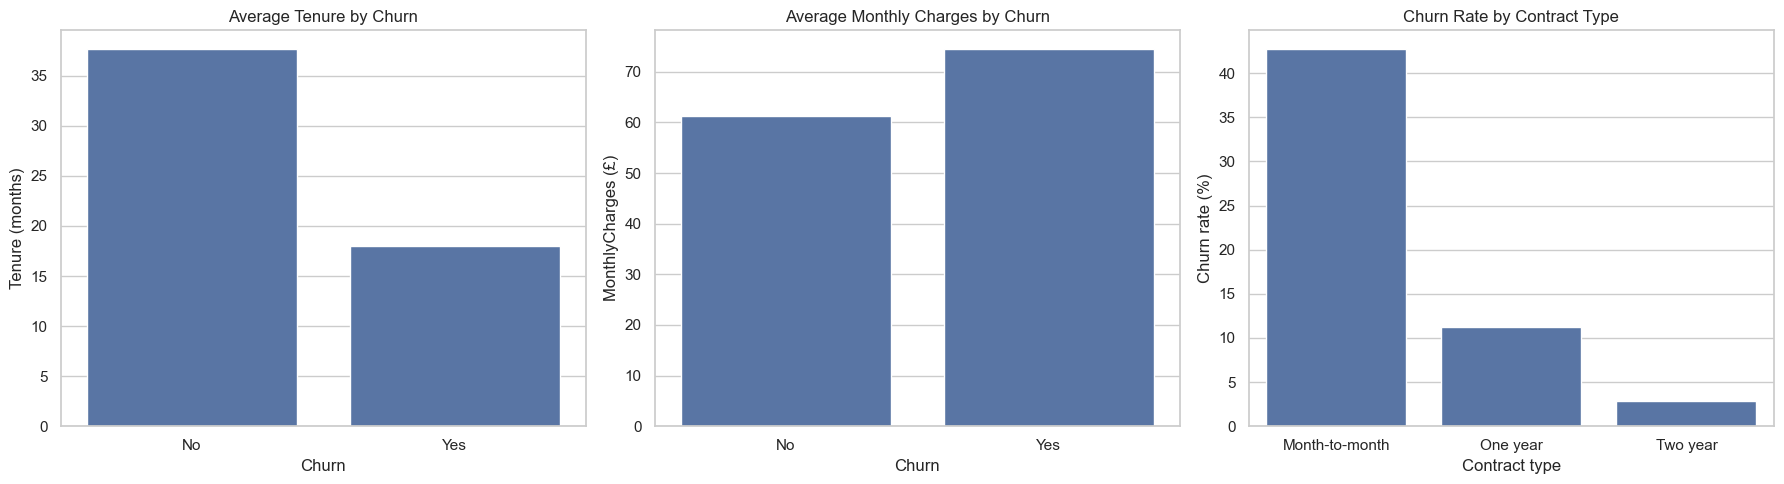

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Avg tenure by churn
sns.barplot(
    data=df,
    x="Churn",
    y="tenure",
    ci=None,              # no error bars
    ax=axes[0]
)
axes[0].set_title("Average Tenure by Churn")
axes[0].set_ylabel("Tenure (months)")
axes[0].set_xlabel("Churn")

# 2) Avg monthly charge by churn
sns.barplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    ci=None,
    ax=axes[1]
)
axes[1].set_title("Average Monthly Charges by Churn")
axes[1].set_ylabel("MonthlyCharges (£)")
axes[1].set_xlabel("Churn")

# 3) Churn rate by contract type
churn_by_contract = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="churn_rate")
)

sns.barplot(
    data=churn_by_contract,
    x="Contract",
    y="churn_rate",
    ax=axes[2]
)
axes[2].set_title("Churn Rate by Contract Type")
axes[2].set_ylabel("Churn rate (%)")
axes[2].set_xlabel("Contract type")

plt.tight_layout()
plt.show()


### EDA Summary — Key Findings

1. **Class imbalance**: 73.5% No / 26.5% Yes → need SMOTE or class_weight in Phase 4
2. **Contract type**: strongest single predictor — month-to-month = 42.7% churn
3. **Tenure**: churned customers avg 5 months vs 18 months retained — early churn is the problem
4. **Monthly charges**: churned customers pay ~£13 more/month on average
5. **Add-on services**: online security & tech support reduce churn significantly
6. **No strong multicollinearity** except TotalCharges ↔ tenure (makes sense — drop one later)


## Phase 3 — Feature Engineering & Preprocessing

### Step 1: Drop useless columns

In [9]:
# ── Phase 3: Feature Engineering & Preprocessing ─────────────────────────────
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/telco_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df.reset_index(drop=True, inplace=True)

# customerID is just a row identifier — zero predictive value
# TotalCharges = tenure × MonthlyCharges (almost), so it's redundant
df.drop(columns=['customerID', 'TotalCharges'], inplace=True)

print("Columns remaining:", df.shape[1])

Columns remaining: 19


### Step 2 - Engineer new features

In [10]:
# --- New feature 1: tenure groups ---
# Short-tenure customers churn most — capture this non-linearity
def tenure_group(tenure):
    if tenure <= 12:   return 'new'        # high risk
    elif tenure <= 24: return 'developing' # medium risk
    elif tenure <= 48: return 'established'
    else:              return 'loyal'      # low risk

df['tenure_group'] = df['tenure'].apply(tenure_group)

# --- New feature 2: number of add-on services ---
# More services = more embedded = less likely to churn
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

df['num_services'] = df[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

# --- New feature 3: avg charge per month of tenure ---
# High charge relative to tenure = churn risk
df['charge_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

print("New features added:")
print(df[['tenure_group', 'num_services', 'charge_per_tenure']].head())

New features added:
  tenure_group  num_services  charge_per_tenure
0          new             1          14.925000
1  established             2           1.627143
2          new             2          17.950000
3  established             3           0.919565
4          new             0          23.566667


### Step 3 - Encode categorical columns

In [11]:
# --- Label encoding: binary Yes/No columns ---
# These have exactly 2 values, so 1 number is enough
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'Churn'
]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# --- One-hot encoding: multi-category columns ---
# These have 3+ values — we need a column per category
# drop_first=True avoids the "dummy variable trap" (multicollinearity)
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaymentMethod', 'tenure_group'
]

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("All dtypes numeric?", all(df.dtypes != 'object'))

Shape after encoding: (7032, 35)
All dtypes numeric? True


### Step 4 - Split into X and y, then train/test split

In [12]:
# --- Separate features (X) from target (y) ---
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Features: {X.shape[1]} columns")
print(f"Target distribution:\n{y.value_counts()}")

# --- Train/test split: 80% train, 20% test ---
# stratify=y ensures both splits keep the same 73/27 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # important for imbalanced data!
)

print(f"\nTraining set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

# Verify stratification worked
print(f"\nTrain churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate:  {y_test.mean()*100:.1f}%")

Features: 34 columns
Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Training set: 5625 rows
Test set:     1407 rows

Train churn rate: 26.6%
Test churn rate:  26.6%


### Step 5 - Fit the scaler on training data

In [13]:
scaler = StandardScaler()
num_cols_to_scale = ['tenure', 'MonthlyCharges', 'charge_per_tenure', 'num_services']

X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
# fit_transform on training ✓ — learns mean and std from training rows only

X_test[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])
# transform only on test ✓ — applies the training mean/std, no new learning

### Step 6 - Save everything for the next phase

In [14]:
# --- Save the processed data so Phase 4 can load it cleanly ---
import pickle

X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

# Save the scaler — you'll need it later when the Streamlit app
# receives new customer data that also needs scaling
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("All Phase 3 outputs saved.")
print(f"Final feature count: {X_train.shape[1]}")

All Phase 3 outputs saved.
Final feature count: 34
